# Integrantes del grupo : Grupo 6
- Monzón Gallegos, Alessandro Facundo
- Ramírez Chuquimarca, Mateo Elías
- Vargas Zeballos, Arantza

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import precision_score, recall_score, f1_score

#Creamos el dataset

In [ ]:
data = {
    "Area": [95,123,118,96,182,86,63,193,155,128,195,115,105,140],
    "Habitaciones": [4,2,2,4,4,4,2,2,2,2,5,5,3,3],
    "Antiguedad": [13,14,22,8,19,5,7,3,29,3,18,22,10,6],
    "Distancia": [12.5,8.0,15.0,5.5,9.0,3.5,18.0,4.0,22.0,6.5,7.5,20.0,2.0,14.0],
    "Precio": [171600,216200,196900,190200,305700,180100,133600,
               320000,242700,216800,357400,219800,198500,241300]
}

df = pd.DataFrame(data)

print(df)

    Area  Habitaciones  Antiguedad  Distancia  Precio
0     95             4          13       12.5  171600
1    123             2          14        8.0  216200
2    118             2          22       15.0  196900
3     96             4           8        5.5  190200
4    182             4          19        9.0  305700
5     86             4           5        3.5  180100
6     63             2           7       18.0  133600
7    193             2           3        4.0  320000
8    155             2          29       22.0  242700
9    128             2           3        6.5  216800
10   195             5          18        7.5  357400
11   115             5          22       20.0  219800
12   105             3          10        2.0  198500
13   140             3           6       14.0  241300


#Creamos la variable objetivo binaria

In [ ]:
y_bin = (df["Precio"] > 200000).astype(int)

print(y_bin)

0     0
1     1
2     0
3     0
4     1
5     0
6     0
7     1
8     1
9     1
10    1
11    1
12    0
13    1
Name: Precio, dtype: int64


In [ ]:
# ¿Cuántas propiedades quedan en cada clase?
print("\nCantidad por clase:\n")

print(y_bin.value_counts())


Cantidad por clase:

Precio
1    8
0    6
Name: count, dtype: int64


In [ ]:
# ¿Está balanceado el dataset?
premium = sum(y_bin == 1)
estandar = sum(y_bin == 0)

print("\nPREMIUM:", premium)
print("ESTÁNDAR:", estandar)

if abs(premium - estandar) <= 2:
    print("\nDataset relativamente balanceado")
else:
    print("\nDataset desbalanceado")


PREMIUM: 8
ESTÁNDAR: 6

Dataset relativamente balanceado


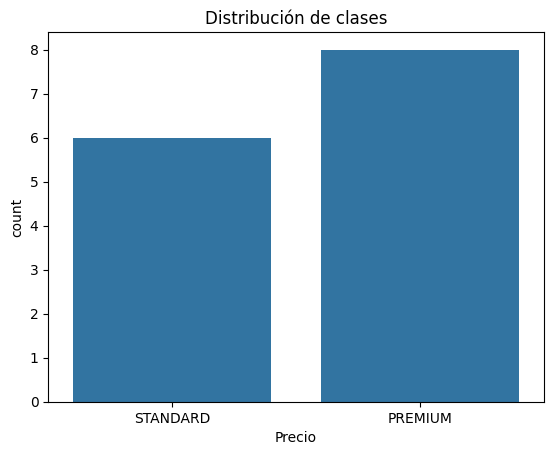

In [ ]:
sns.countplot(x=y_bin)
plt.title("Distribución de clases")
plt.xticks([0,1], ["STANDARD", "PREMIUM"])
plt.show()

# Vemos la dispersión y correlación de nuestro dataset

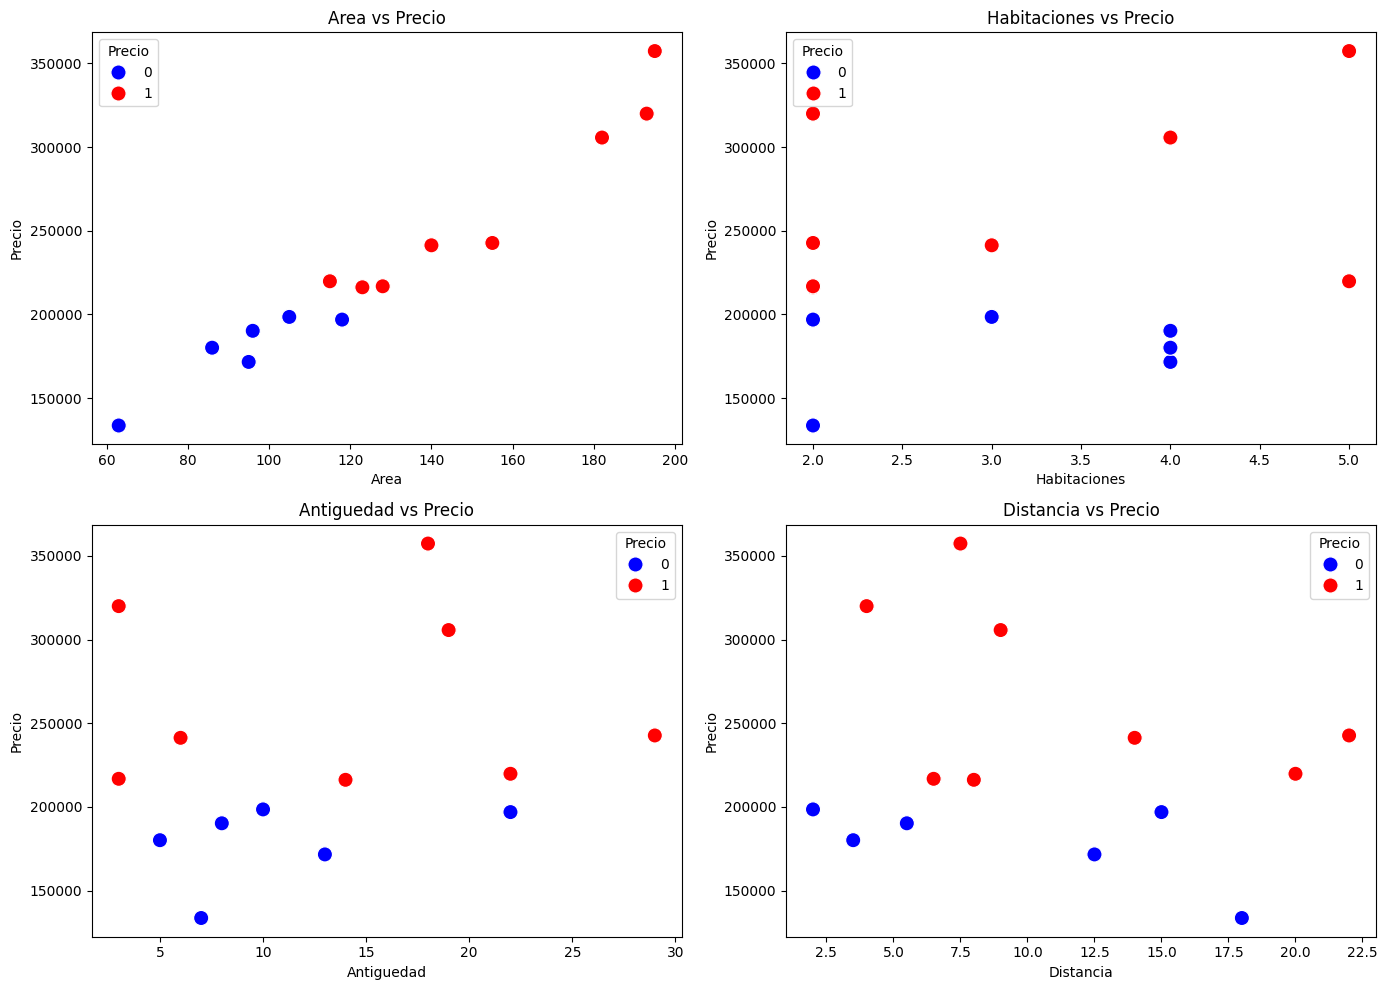

In [ ]:
features = ["Area", "Habitaciones", "Antiguedad", "Distancia"]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

for i, feature in enumerate(features):
    sns.scatterplot(
        data=df,
        x=feature,
        y="Precio",
        hue=y_bin,
        palette={0:"blue", 1:"red"},
        s=120,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} vs Precio")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Precio")

plt.tight_layout()
plt.show()

Los scatterplots evidencian que el área presenta la relación positiva más clara con el precio de las propiedades, mostrando además una separación visible entre las clases PREMIUM y STANDARD. En contraste, variables como antigüedad presenta mayor dispersión, aunque mantienen tendencias negativas consistentes con la intuición económica del problema.

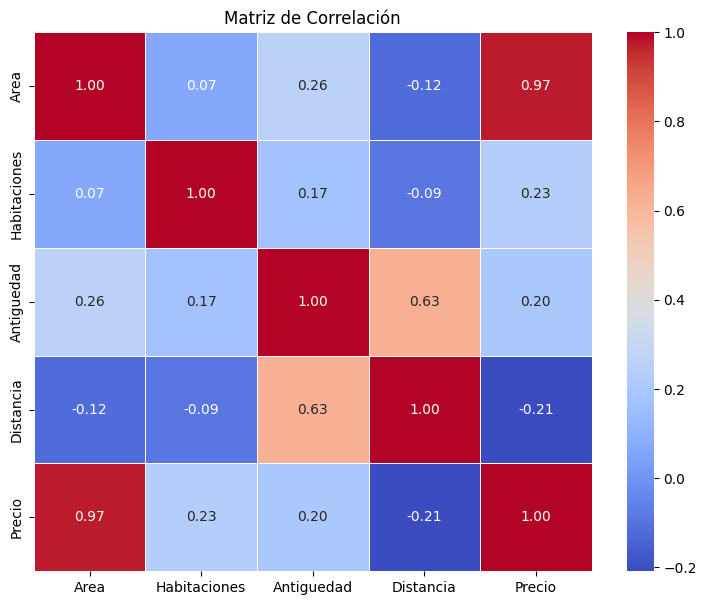

In [ ]:
corr = df.corr(numeric_only=True)

# Graficar heatmap
plt.figure(figsize=(9,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de Correlación")
plt.show()

# Funciones a utilizar

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
def entrenar_logistica(X, y, lr=0.01, epochs=2000):

    # Cantidad de muestras
    m = X.shape[0]

    # Pesos igual a 0
    w = np.zeros((X.shape[1],1))

    y = y.reshape(-1,1)

    # Lista de perdida
    loss_historial = []

    for epoch in range(epochs):

        # Predicción
        z = X @ w
        y_hat = sigmoid(z)

        # Binary Cross Entropy
        loss = -(1/m) * np.sum(
            y*np.log(y_hat + 1e-8) +
            (1-y)*np.log(1-y_hat + 1e-8)
        )

        loss_historial.append(loss)

        # Calculamos la gradiente
        gradiente = (1/m) * (X.T @ (y_hat - y))

        # Y Actualizamos los pesos
        w = w - lr * gradiente

    return w, loss_historial

In [ ]:
def evaluar_modelo(X, y, w):

    probs = sigmoid(X @ w)

    predicciones = (probs >= 0.5).astype(int)

    acc = accuracy_score(y, predicciones)

    return acc, predicciones

In [ ]:
def log_likelihood(y, p):
    eps = 1e-8
    return np.sum(
        y*np.log(p + eps) + (1-y)*np.log(1-p + eps)
    )

In [ ]:
def pseudo_r2_mcfadden(y, p):
    p_mean = np.mean(y)
    ll_model = log_likelihood(y, p)
    ll_null = log_likelihood(y, np.full_like(y, p_mean))

    return 1 - (ll_model / ll_null)

In [ ]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title(title)
    plt.show()

In [ ]:
def report(y_true, y_pred, name):
    print(f"\n{name}")
    print("-"*30)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))

#Modelos logísticos univariados

## Para Area

In [ ]:
X_area = df[["Area"]].values

In [ ]:
scaler_area = StandardScaler()

X_area = scaler_area.fit_transform(X_area)

In [ ]:
X_area = np.hstack((np.ones((X_area.shape[0],1)), X_area))

In [ ]:
w_area, loss_area = entrenar_logistica(X_area, y_bin.values)

In [ ]:
acc_area, pred_area = evaluar_modelo(X_area, y_bin.values, w_area)

print("MODELO SOLO ÁREA")
print("-----------------")

print(f"w0 = {w_area[0][0]:.4f}")
print(f"w1 = {w_area[1][0]:.4f}")

print(f"\nAccuracy = {acc_area:.4f}")

MODELO SOLO ÁREA
-----------------
w0 = 0.6249
w1 = 2.4087

Accuracy = 0.8571


## Para Habitaciones

In [ ]:
X_hab = df[["Habitaciones"]].values

In [ ]:
scaler_hab = StandardScaler()
X_hab = scaler_hab.fit_transform(X_hab)

In [ ]:
X_hab = np.hstack((np.ones((X_hab.shape[0],1)), X_hab))

In [ ]:
w_hab, loss_hab = entrenar_logistica(X_hab, y_bin.values, lr=0.01, epochs=2000)

In [ ]:
acc_hab, pred_hab = evaluar_modelo(X_hab, y_bin.values, w_hab)

print("MODELO SOLO HABITACIONES")
print("-------------------------")
print(f"w0 = {w_hab[0][0]:.4f}")
print(f"w2 = {w_hab[1][0]:.4f}")
print(f"Accuracy = {acc_hab:.4f}")

MODELO SOLO HABITACIONES
-------------------------
w0 = 0.2857
w2 = -0.0367
Accuracy = 0.5714


## Para Antiguedad

In [ ]:
X_ant = df[["Antiguedad"]].values

In [ ]:
scaler_ant = StandardScaler()
X_ant = scaler_ant.fit_transform(X_ant)

In [ ]:
X_ant = np.hstack((np.ones((X_ant.shape[0],1)), X_ant))

In [ ]:
w_ant, loss_ant = entrenar_logistica(X_ant, y_bin.values, lr=0.01, epochs=2000)

In [ ]:
acc_ant, pred_ant = evaluar_modelo(X_ant, y_bin.values, w_ant)

print("MODELO SOLO ANTIGÜEDAD")
print("-----------------------")
print(f"w0 = {w_ant[0][0]:.4f}")
print(f"w3 = {w_ant[1][0]:.4f}")
print(f"Accuracy = {acc_ant:.4f}")

MODELO SOLO ANTIGÜEDAD
-----------------------
w0 = 0.3013
w3 = 0.4509
Accuracy = 0.5000


## Para Distancia

In [ ]:
X_dist = df[["Distancia"]].values

In [ ]:
scaler_dist = StandardScaler()
X_dist = scaler_dist.fit_transform(X_dist)

In [ ]:
X_dist = np.hstack((np.ones((X_dist.shape[0],1)), X_dist))

In [ ]:
w_dist, loss_dist = entrenar_logistica(X_dist, y_bin.values, lr=0.01, epochs=2000)

In [ ]:
# Evaluamos
acc_dist, pred_dist = evaluar_modelo(X_dist, y_bin.values, w_dist)

print("MODELO SOLO DISTANCIA")
print("----------------------")
print(f"w0 = {w_dist[0][0]:.4f}")
print(f"w4 = {w_dist[1][0]:.4f}")
print(f"Accuracy = {acc_dist:.4f}")

MODELO SOLO DISTANCIA
----------------------
w0 = 0.2932
w4 = 0.3209
Accuracy = 0.6429


# Modelo logístico completo

In [ ]:
X_full = df[["Area","Habitaciones","Antiguedad","Distancia"]].values

In [ ]:
scaler_full = StandardScaler()

X_full = scaler_full.fit_transform(X_full)

In [ ]:
X_full = np.hstack((np.ones((X_full.shape[0],1)), X_full))

In [ ]:
w_full, loss_full = entrenar_logistica(
    X_full,
    y_bin.values,
    lr=0.01,
    epochs=3000
)

In [ ]:
print("MODELO COMPLETO")
print("----------------")

for i, peso in enumerate(w_full):
    print(f"w{i} = {peso[0]:.4f}")

MODELO COMPLETO
----------------
w0 = 0.7637
w1 = 2.8147
w2 = 0.0141
w3 = -0.3690
w4 = 0.6973


In [ ]:
acc_full, pred_full = evaluar_modelo(
    X_full,
    y_bin.values,
    w_full
)

print("\nAccuracy modelo completo:", acc_full)


Accuracy modelo completo: 0.9285714285714286


In [ ]:
cm = confusion_matrix(y_bin.values, pred_full)

print("\nMatriz de Confusión:\n")
print(cm)


Matriz de Confusión:

[[5 1]
 [0 8]]


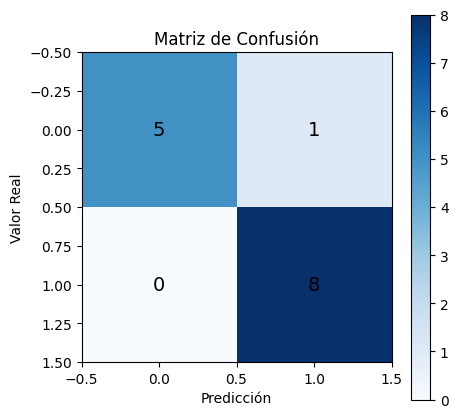

In [ ]:
plt.figure(figsize=(5,5))

plt.imshow(cm, cmap="Blues")

plt.title("Matriz de Confusión")
plt.colorbar()

plt.xlabel("Predicción")
plt.ylabel("Valor Real")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                 ha='center',
                 va='center',
                 color='black',
                 fontsize=14)

plt.show()

# Predicción de la clase de una propiedad de 175 m², 4 hab., 8 años y 6 km del centro.

In [ ]:
nueva_casa = np.array([[175,4,8,6]])

In [ ]:
nueva_casa_norm = scaler_full.transform(nueva_casa)

In [ ]:
nueva_casa_norm = np.hstack((np.ones((1,1)), nueva_casa_norm))

In [ ]:
prob = sigmoid(nueva_casa_norm @ w_full)

print("\nProbabilidad PREMIUM:")
print(prob[0][0])


Probabilidad PREMIUM:
0.9793670979114337


In [ ]:
clase = (prob >= 0.5).astype(int)

if clase == 1:
    print("\nLa casa es PREMIUM")
else:
    print("\nLa casa es ESTÁNDAR")


La casa es PREMIUM


# Grafico de nuestro modelo

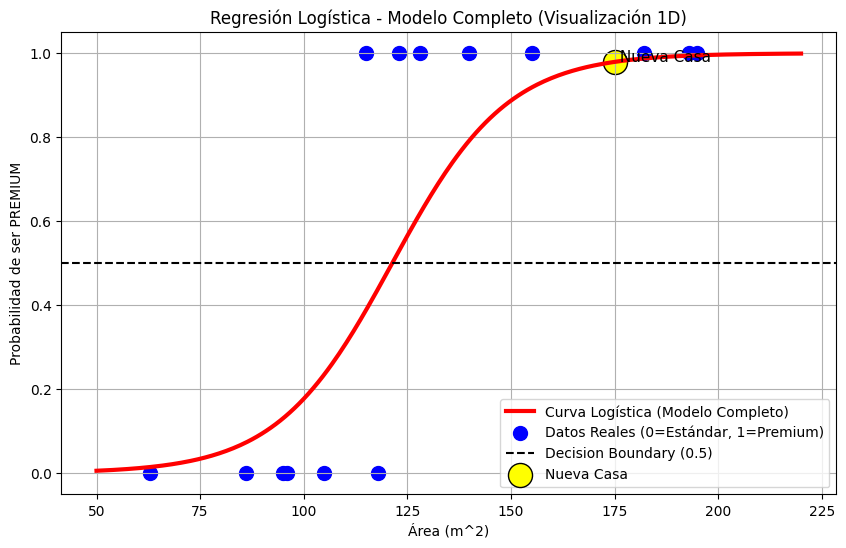

In [ ]:
# Rango de Área (variable principal para visualizar)

areas = np.linspace(50, 220, 300)

habitaciones_fijas = 4
antiguedad_fija = 8
distancia_fija = 6

# Construimso nuestro dataset para la curva
X_curve = np.column_stack((
    areas,
    np.full(len(areas), habitaciones_fijas),
    np.full(len(areas), antiguedad_fija),
    np.full(len(areas), distancia_fija)
))

# Normalizamos
X_curve_norm = scaler_full.transform(X_curve)

# Agregamos
X_curve_b = np.hstack((
    np.ones((X_curve_norm.shape[0], 1)),
    X_curve_norm
))

# Probabilidades
probs_curve = sigmoid(X_curve_b @ w_full)

# Nueva casa

nueva_casa = np.array([[175, 4, 8, 6]])

nueva_casa_norm = scaler_full.transform(nueva_casa)

nueva_casa_b = np.hstack((
    np.ones((1,1)),
    nueva_casa_norm
))

prob_nueva = sigmoid(nueva_casa_b @ w_full)

# DATOS REALES
y_bin_array = y_bin.values

# GRÁFICO

plt.figure(figsize=(10,6))

plt.plot(
    areas,
    probs_curve,
    color='red',
    linewidth=3,
    label='Curva Logística (Modelo Completo)'
)

plt.scatter(
    df["Area"],
    y_bin_array,
    color='blue',
    s=100,
    label='Datos Reales (0=Estándar, 1=Premium)'
)

plt.axhline(
    y=0.5,
    color='black',
    linestyle='--',
    label='Decision Boundary (0.5)'
)

plt.scatter(
    175,
    prob_nueva,
    color='yellow',
    edgecolors='black',
    s=300,
    label='Nueva Casa'
)

plt.text(
    175,
    prob_nueva[0][0],
    ' Nueva Casa',
    fontsize=11
)

plt.xlabel("Área (m^2)")
plt.ylabel("Probabilidad de ser PREMIUM")

plt.title("Regresión Logística - Modelo Completo (Visualización 1D)")

plt.legend()
plt.grid(True)

plt.show()

# Comparamos nuestro modelo con un modelo con normalización min-max y sin normalizar

COMPARACIÓN DE MODELOS
----------------------------
Sin normalizar -> Accuracy: 0.7857 | MSE: 0.1457
Z-score        -> Accuracy: 0.9286 | MSE: 0.0615
MinMax         -> Accuracy: 0.9286 | MSE: 0.1495


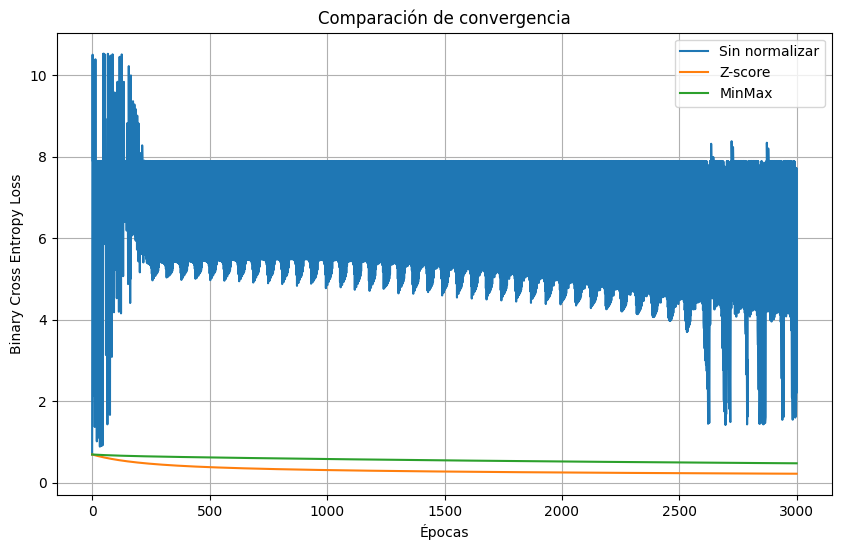

In [ ]:
X_raw = df[["Area","Habitaciones","Antiguedad","Distancia"]].values
y = y_bin.values.reshape(-1,1)

# SIN NORMALIZAR

X_no = np.hstack((np.ones((X_raw.shape[0],1)), X_raw))

w_no, loss_no = entrenar_logistica(
    X_no,
    y.flatten(),
    lr=0.01,
    epochs=3000
)

acc_no, pred_no = evaluar_modelo(X_no, y.flatten(), w_no)

# Calculamos sus Probabilidades
prob_no = sigmoid(X_no @ w_no)

# MSE
mse_no = mean_squared_error(y, prob_no)


# Con Z-SCORE (NUestro modelo)

scaler_z = StandardScaler()

X_z = scaler_z.fit_transform(X_raw)

X_z = np.hstack((np.ones((X_z.shape[0],1)), X_z))

w_z, loss_z = entrenar_logistica(
    X_z,
    y.flatten(),
    lr=0.01,
    epochs=3000
)

acc_z, pred_z = evaluar_modelo(X_z, y.flatten(), w_z)

prob_z = sigmoid(X_z @ w_z)

mse_z = mean_squared_error(y, prob_z)

# Con normalización MIN-MAX

scaler_mm = MinMaxScaler()

X_mm = scaler_mm.fit_transform(X_raw)

X_mm = np.hstack((np.ones((X_mm.shape[0],1)), X_mm))

w_mm, loss_mm = entrenar_logistica(
    X_mm,
    y.flatten(),
    lr=0.01,
    epochs=3000
)

acc_mm, pred_mm = evaluar_modelo(X_mm, y.flatten(), w_mm)

prob_mm = sigmoid(X_mm @ w_mm)

mse_mm = mean_squared_error(y, prob_mm)

# RESULTADOS

print("COMPARACIÓN DE MODELOS")
print("----------------------------")

print(f"Sin normalizar -> Accuracy: {acc_no:.4f} | MSE: {mse_no:.4f}")
print(f"Z-score        -> Accuracy: {acc_z:.4f} | MSE: {mse_z:.4f}")
print(f"MinMax         -> Accuracy: {acc_mm:.4f} | MSE: {mse_mm:.4f}")

# CURVAS DE LOSS

plt.figure(figsize=(10,6))

plt.plot(loss_no, label="Sin normalizar")
plt.plot(loss_z, label="Z-score")
plt.plot(loss_mm, label="MinMax")

plt.xlabel("Épocas")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Comparación de convergencia")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
print("\nPESOS Z-SCORE")
print(w_z)

print("\nPESOS MINMAX")
print(w_mm)

print("\nPESOS SIN NORMALIZAR")
print(w_no)


PESOS Z-SCORE
[[ 0.76374741]
 [ 2.81467498]
 [ 0.01405531]
 [-0.36895533]
 [ 0.69732831]]

PESOS MINMAX
[[-0.74967335]
 [ 2.20956303]
 [-0.31592571]
 [ 0.29642317]
 [ 0.27264585]]

PESOS SIN NORMALIZAR
[[-2.7393534 ]
 [ 0.24203096]
 [-7.52044176]
 [-0.13444001]
 [-0.64840024]]


# Calculamos las metricas de cada modelo para ver cual es mejor

In [ ]:
# Probabilidad de cada modelo

p_no = sigmoid(X_no @ w_no)
p_z = sigmoid(X_z @ w_z)
p_mm = sigmoid(X_mm @ w_mm)

r2_no = pseudo_r2_mcfadden(y.flatten(), p_no.flatten())
r2_z = pseudo_r2_mcfadden(y.flatten(), p_z.flatten())
r2_mm = pseudo_r2_mcfadden(y.flatten(), p_mm.flatten())

print("R^2")
print("---------------------")
print(f"Sin normalizar: {r2_no:.4f}")
print(f"Z-score:        {r2_z:.4f}")
print(f"MinMax:         {r2_mm:.4f}")

R2
---------------------
Sin normalizar: 0.8550
Z-score:        0.9790
MinMax:         0.9547


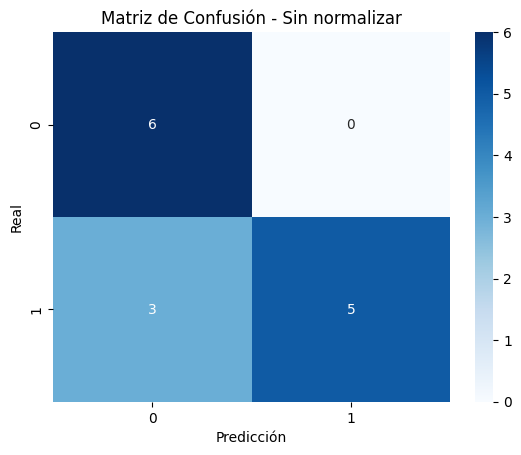

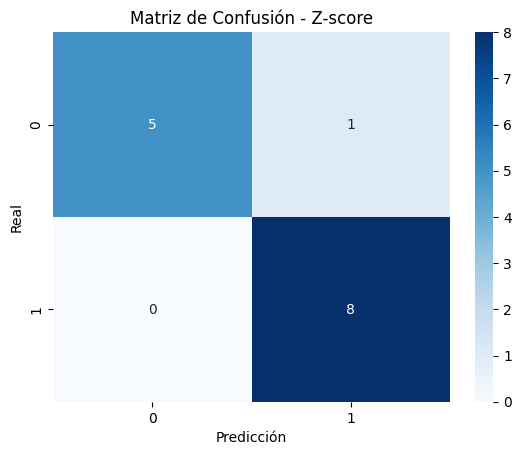

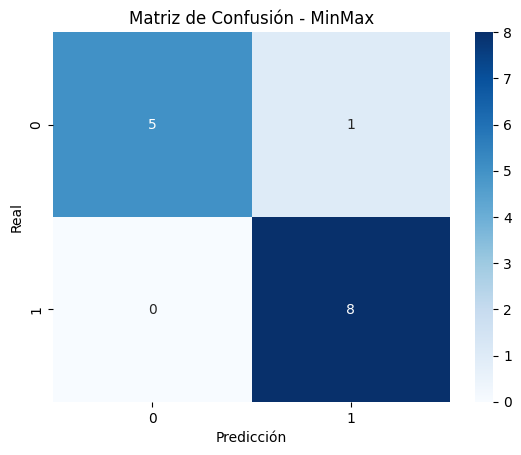

In [ ]:
plot_cm(y, pred_no, "Matriz de Confusión - Sin normalizar")
plot_cm(y, pred_z, "Matriz de Confusión - Z-score")
plot_cm(y, pred_mm, "Matriz de Confusión - MinMax")

In [ ]:
report(y, pred_no, "SIN NORMALIZAR")
report(y, pred_z, "Z-SCORE")
report(y, pred_mm, "MIN-MAX")


SIN NORMALIZAR
------------------------------
Accuracy : 0.7857142857142857
Precision: 1.0
Recall   : 0.625
F1-score : 0.7692307692307693

Z-SCORE
------------------------------
Accuracy : 0.9285714285714286
Precision: 0.8888888888888888
Recall   : 1.0
F1-score : 0.9411764705882353

MIN-MAX
------------------------------
Accuracy : 0.9285714285714286
Precision: 0.8888888888888888
Recall   : 1.0
F1-score : 0.9411764705882353
